# PPE Safety Detection System - Exploration Notebook

## Project Overview

This notebook documents the early exploration and training results for the **PPE Safety Detection System** midterm project.

The goal of this project is to use computer vision to detect workplace Personal Protective Equipment (PPE), including:

- Boots
- Gloves
- Helmets
- Human workers
- Safety vests

The project uses **YOLO11n** object detection through the Ultralytics framework.


## 1. Dataset Summary

The dataset used for this project is a Construction PPE Detection dataset exported in YOLO format.

The dataset includes:

- Training images
- Validation images
- Test images
- YOLO label files
- `data.yaml` configuration file


In [7]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)

print("Current directory:", os.getcwd())

Current directory: /home/phredo/projects/ITAI1378_PPE_Detection


In [8]:
from pathlib import Path

train_images = list(Path("train/images").glob("*"))
valid_images = list(Path("valid/images").glob("*"))
test_images = list(Path("test/images").glob("*"))

print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(valid_images)}")
print(f"Test images: {len(test_images)}")


Training images: 4380
Validation images: 420
Test images: 211


## 2. Class Labels

The dataset contains five object classes:

| Class ID | Label |
|---:|---|
| 0 | boots |
| 1 | gloves |
| 2 | helmet |
| 3 | human |
| 4 | vest |


In [9]:
import yaml

with open("data.yaml", "r") as f:
    data_config = yaml.safe_load(f)

data_config


{'train': 'train/images',
 'val': 'valid/images',
 'test': 'test/images',
 'nc': 5,
 'names': ['boots', 'gloves', 'helmet', 'human', 'vest'],
 'roboflow': {'workspace': 'huiyao-hu-sj18e',
  'project': 'construction-ppe-detection',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/huiyao-hu-sj18e/construction-ppe-detection/dataset/1'}}

## 3. Sample Training Images

The following cell displays a random sample of training images from the dataset.


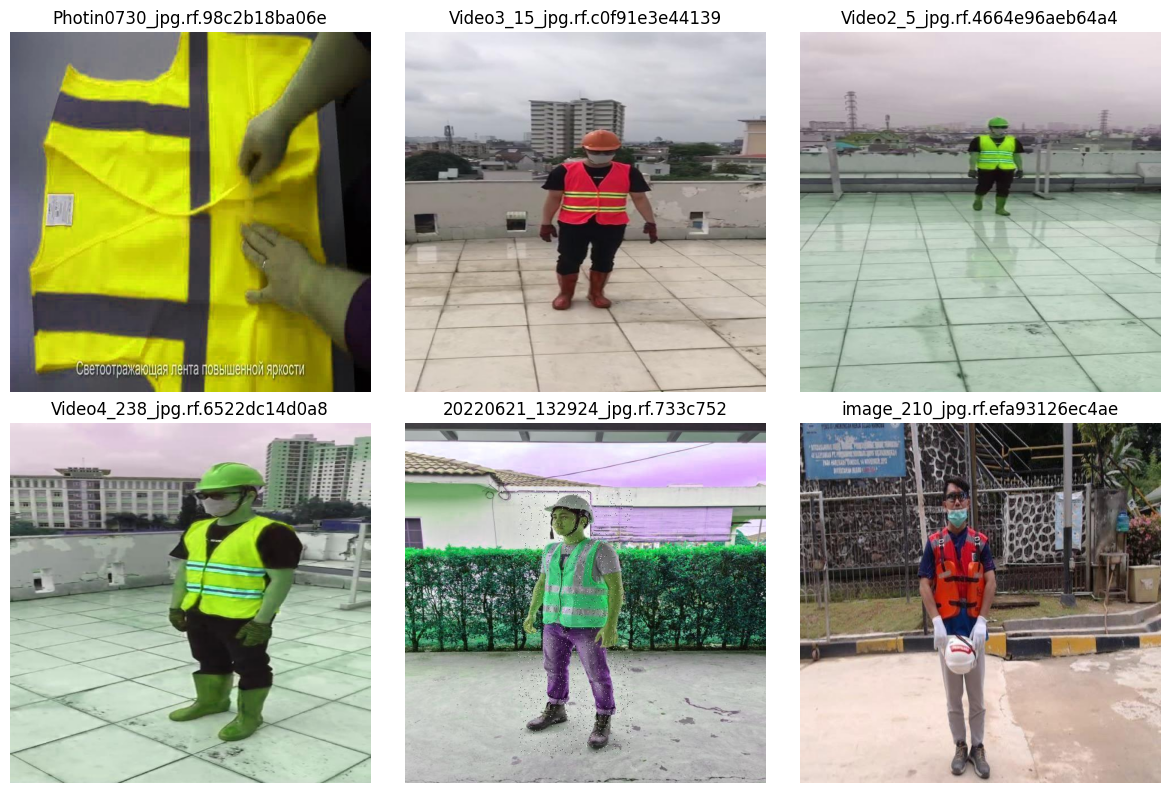

In [10]:
import random
from PIL import Image
import matplotlib.pyplot as plt

sample_images = random.sample(train_images, min(6, len(train_images)))

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_path.name[:30])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Training Results

A YOLO11n model was trained for 20 epochs using the Construction PPE Detection dataset.

Final validation results:

| Metric | Result |
|---|---:|
| Precision | 90.8% |
| Recall | 90.6% |
| mAP50 | 93.0% |
| mAP50-95 | 73.9% |

The model performed especially well on boots, helmets, human workers, and safety vests. Gloves were the weakest class, likely because they are smaller objects and are often partially hidden.


## 5. Training Curves

The training results chart shows model performance across the 20 training epochs.


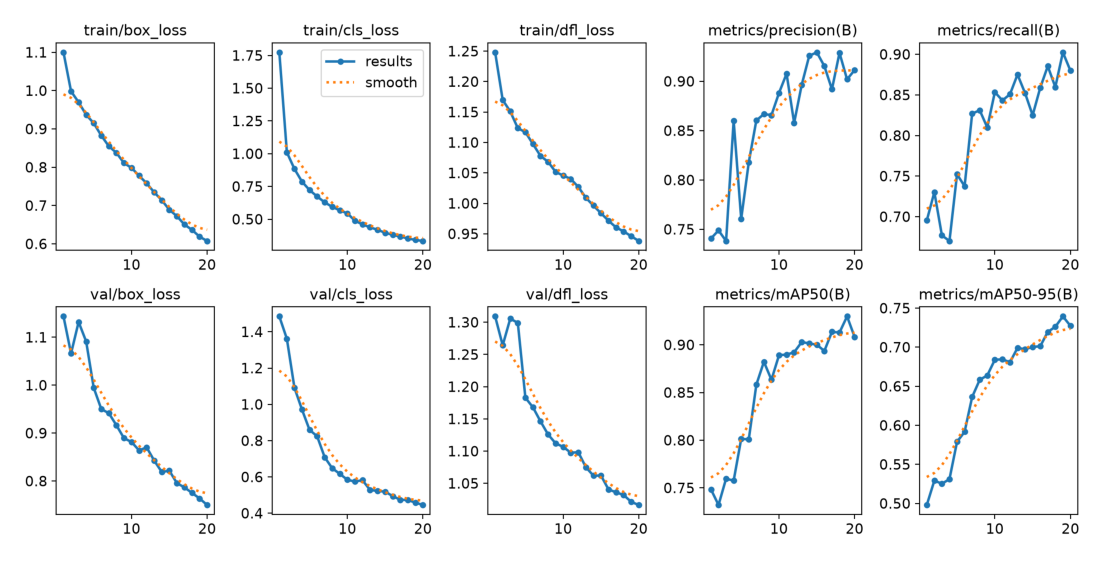

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("outputs/results_20_epochs.png")

plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.show()


## 6. Confusion Matrix

The confusion matrix helps show where the model correctly classified objects and where it confused one class with another.


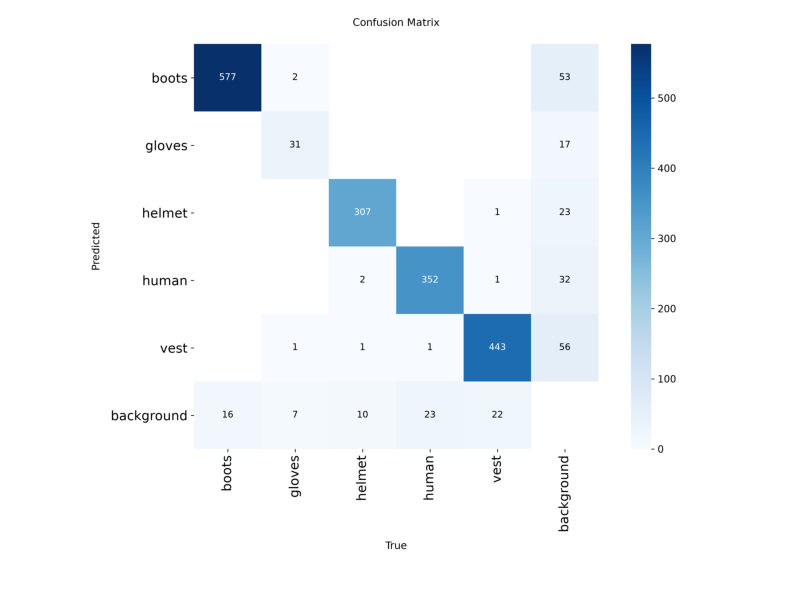

In [12]:
img = Image.open("outputs/confusion_matrix_20_epochs.png")

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()


## 7. Sample Predictions

The sample prediction image shows how the trained YOLO11n model detects PPE objects in validation images.


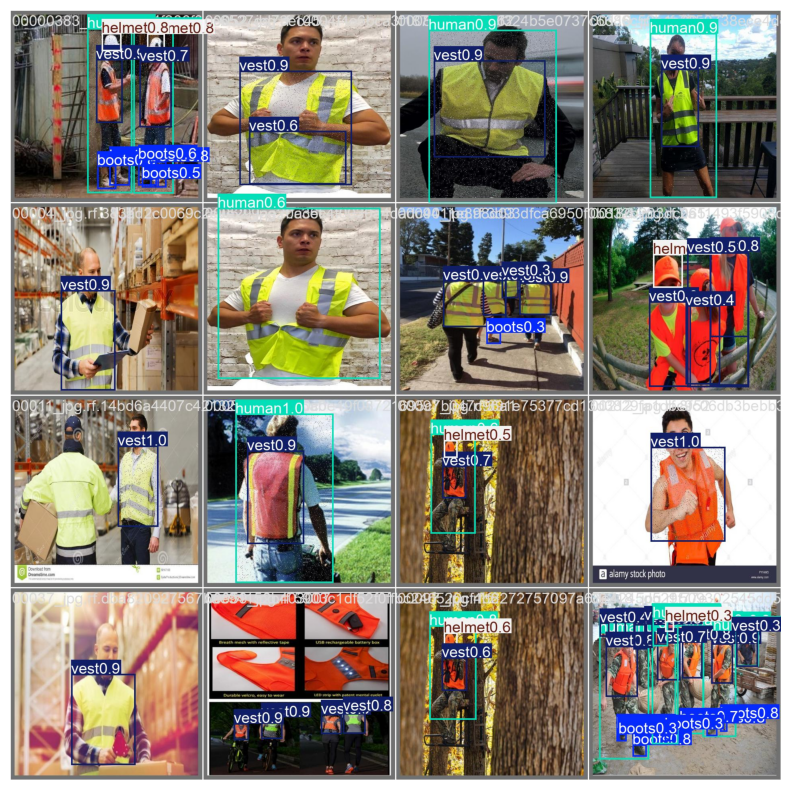

In [13]:
img = Image.open("outputs/sample_predictions_20_epochs.jpg")

plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.show()


## 8. Observations

Key observations from the initial model training:

- The model achieved strong overall detection performance after 20 epochs.
- Helmet, vest, human, and boots detection performed very well.
- Glove detection was weaker than the other classes.
- The weaker glove performance is likely due to gloves being smaller, harder to see, and sometimes partially blocked.
- The model is already strong enough to support the midterm project proposal and final demonstration.

## 9. Next Steps

Planned next steps:

- Test the trained model on additional images.
- Add more examples to the README.
- Create the project proposal slide deck.
- Prepare a short demo showing input images and detected PPE objects.
